# sin(x) 的 9 点拉格朗日插值

区间：$[0,2\pi]$  
节点数：9

本 Notebook 包含：

1. 一次拉格朗日插值（分段线性插值）
2. 二次拉格朗日插值（局部抛物线插值）
3. 八次拉格朗日插值（9 点全局插值）
4. 三种方法的误差与对比

所有图片会在 Notebook 中显示，并自动保存为 PNG 文件。

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange


# 如果 Figures 文件夹不存在，则自动创建
os.makedirs("Figures", exist_ok=True)


def linear_interpolation(x_nodes, y_nodes, x):
    """
    一次拉格朗日插值，即分段线性插值。

    对每个计算点，选取其所在区间的两个相邻节点，
    再调用 scipy.interpolate.lagrange 构造一次多项式。
    """

    y_linear = np.empty_like(x, dtype=float)
    n_nodes = len(x_nodes)

    for k, x_value in enumerate(x):
        if x_value <= x_nodes[0]:
            start = 0
        elif x_value >= x_nodes[-1]:
            start = n_nodes - 2
        else:
            right = np.searchsorted(x_nodes, x_value, side="right")
            start = right - 1

        polynomial = lagrange(
            x_nodes[start:start + 2],
            y_nodes[start:start + 2]
        )
        y_linear[k] = polynomial(x_value)

    return y_linear


def quadratic_interpolation(x_nodes, y_nodes, x):
    """
    二次拉格朗日插值，即局部抛物线插值。

    对每个计算点，选取附近的三个连续节点，
    再调用 scipy.interpolate.lagrange 构造二次多项式。
    """

    y_quadratic = np.empty_like(x, dtype=float)
    n_nodes = len(x_nodes)

    for k, x_value in enumerate(x):
        nearest = int(np.argmin(np.abs(x_nodes - x_value)))
        start = nearest - 1
        start = max(start, 0)
        start = min(start, n_nodes - 3)

        polynomial = lagrange(
            x_nodes[start:start + 3],
            y_nodes[start:start + 3]
        )
        y_quadratic[k] = polynomial(x_value)

    return y_quadratic

In [2]:
# 在区间 [0, 2π] 上构造 9 个等距插值节点
x_nodes = np.linspace(0.0, 2.0 * np.pi, 9)
y_nodes = np.sin(x_nodes)

# 构造致密网格，用于绘图和误差计算
x = np.linspace(0.0, 2.0 * np.pi, 2000)
y_true = np.sin(x)

# 一次拉格朗日插值
y_linear = linear_interpolation(x_nodes, y_nodes, x)
error_linear = np.abs(y_linear - y_true)

# 二次拉格朗日插值
y_quadratic = quadratic_interpolation(x_nodes, y_nodes, x)
error_quadratic = np.abs(y_quadratic - y_true)

# 八次全局拉格朗日插值
polynomial_degree8 = lagrange(x_nodes, y_nodes)
y_degree8 = polynomial_degree8(x)
error_degree8 = np.abs(y_degree8 - y_true)


一次插值最大误差： 0.07037749588313058
二次插值最大误差： 0.029097277757869522
八次插值最大误差： 0.0012055371435691076


/tmp/ipykernel_518500/1209820319.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/linear_lagrange.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1209820319.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/linear_lagrange.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1209820319.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/linear_lagrange.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1209820319.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" 

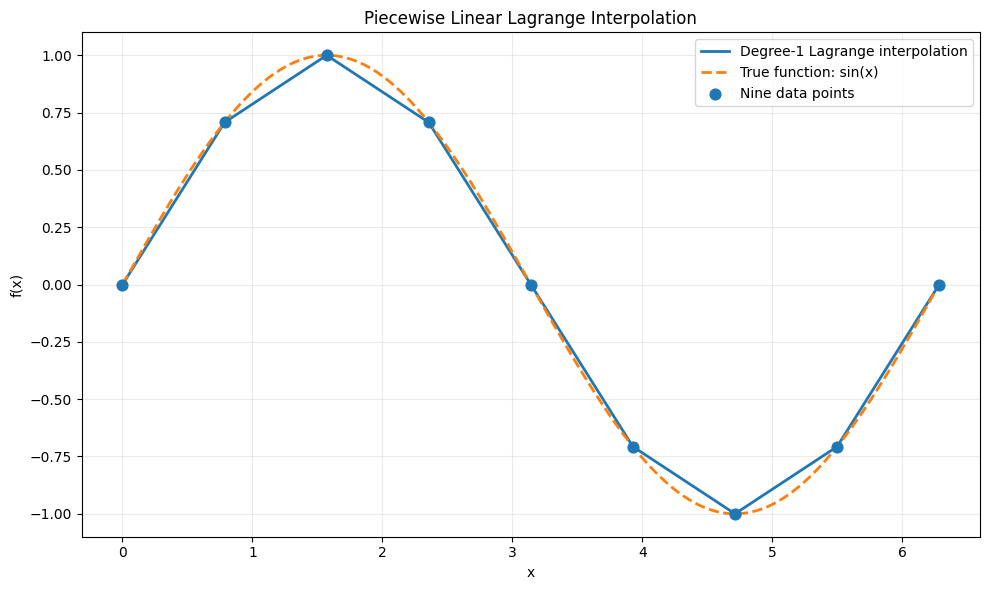

/tmp/ipykernel_518500/1209820319.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/linear_lagrange_error.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1209820319.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/linear_lagrange_error.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1209820319.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/linear_lagrange_error.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1209820319.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbo

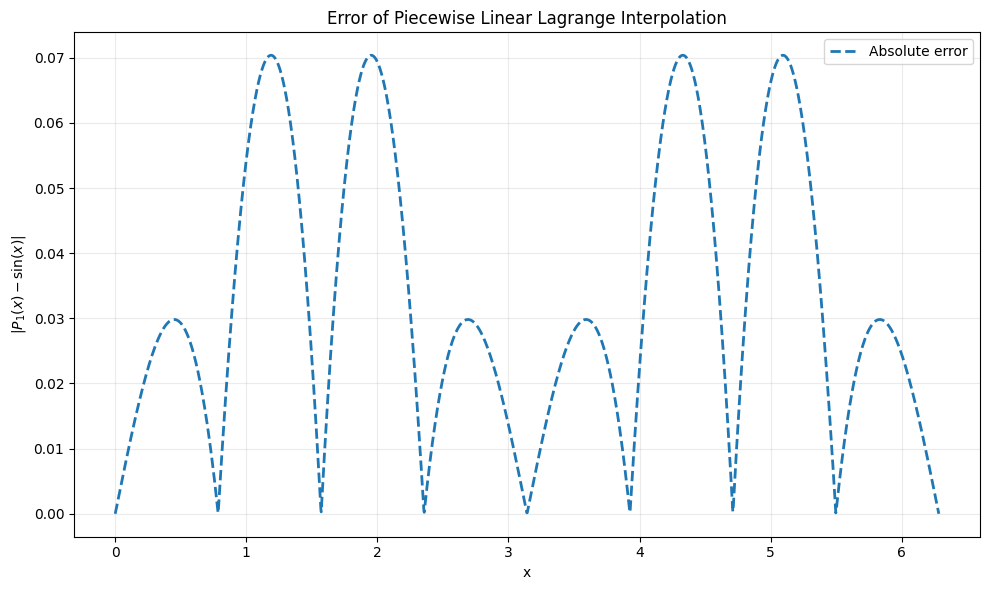

In [3]:
# 一次拉格朗日插值曲线
plt.figure(figsize=(10, 6))
plt.scatter(x_nodes, y_nodes, s=60, label="Nine data points", zorder=3)
plt.plot(x, y_linear, linewidth=2, label="Degree-1 Lagrange interpolation")
plt.plot(x, y_true, "--", linewidth=2, label="True function: sin(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Piecewise Linear Lagrange Interpolation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/linear_lagrange.png", dpi=300, bbox_inches="tight")
plt.show()

# 一次拉格朗日插值误差
plt.figure(figsize=(10, 6))
plt.plot(x, error_linear, "--", linewidth=2, label="Absolute error")
plt.xlabel("x")
plt.ylabel(r"$|P_1(x)-\sin(x)|$")
plt.title("Error of Piecewise Linear Lagrange Interpolation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/linear_lagrange_error.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_518500/1642143226.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/quadratic_lagrange.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1642143226.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/quadratic_lagrange.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1642143226.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/quadratic_lagrange.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1642143226.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_

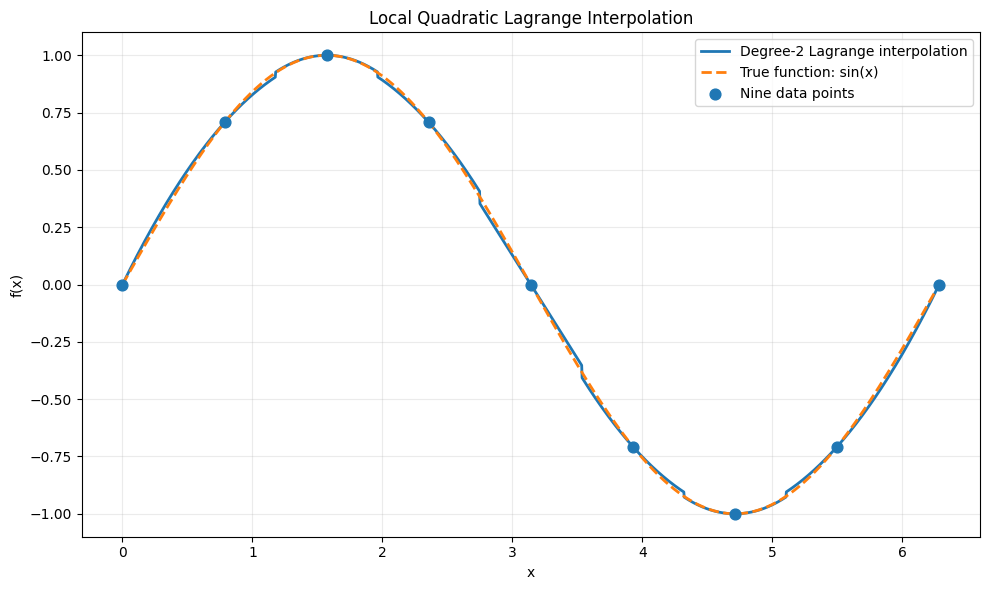

/tmp/ipykernel_518500/1642143226.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/quadratic_lagrange_error.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1642143226.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/quadratic_lagrange_error.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1642143226.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/quadratic_lagrange_error.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/1642143226.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argu

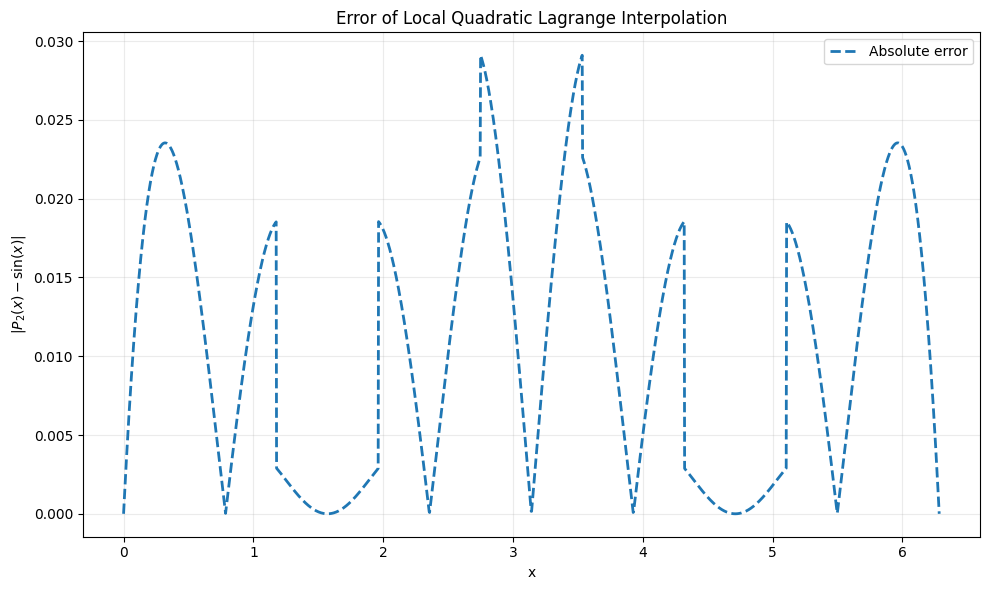

In [4]:
# 二次拉格朗日插值曲线
plt.figure(figsize=(10, 6))
plt.scatter(x_nodes, y_nodes, s=60, label="Nine data points", zorder=3)
plt.plot(x, y_quadratic, linewidth=2, label="Degree-2 Lagrange interpolation")
plt.plot(x, y_true, "--", linewidth=2, label="True function: sin(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Local Quadratic Lagrange Interpolation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/quadratic_lagrange.png", dpi=300, bbox_inches="tight")
plt.show()

# 二次拉格朗日插值误差
plt.figure(figsize=(10, 6))
plt.plot(x, error_quadratic, "--", linewidth=2, label="Absolute error")
plt.xlabel("x")
plt.ylabel(r"$|P_2(x)-\sin(x)|$")
plt.title("Error of Local Quadratic Lagrange Interpolation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/quadratic_lagrange_error.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_518500/515586093.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/degree8_lagrange.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/515586093.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/degree8_lagrange.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/515586093.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/degree8_lagrange.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/515586093.py:12: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" w

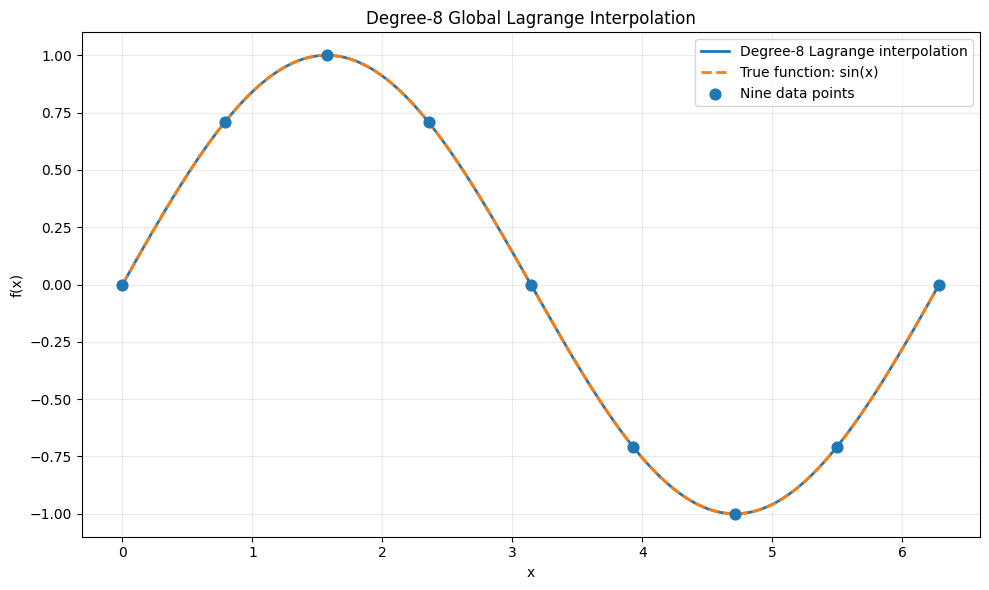

/tmp/ipykernel_518500/515586093.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/degree8_lagrange_error.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/515586093.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/degree8_lagrange_error.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/515586093.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/degree8_lagrange_error.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/515586093.py:24: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox

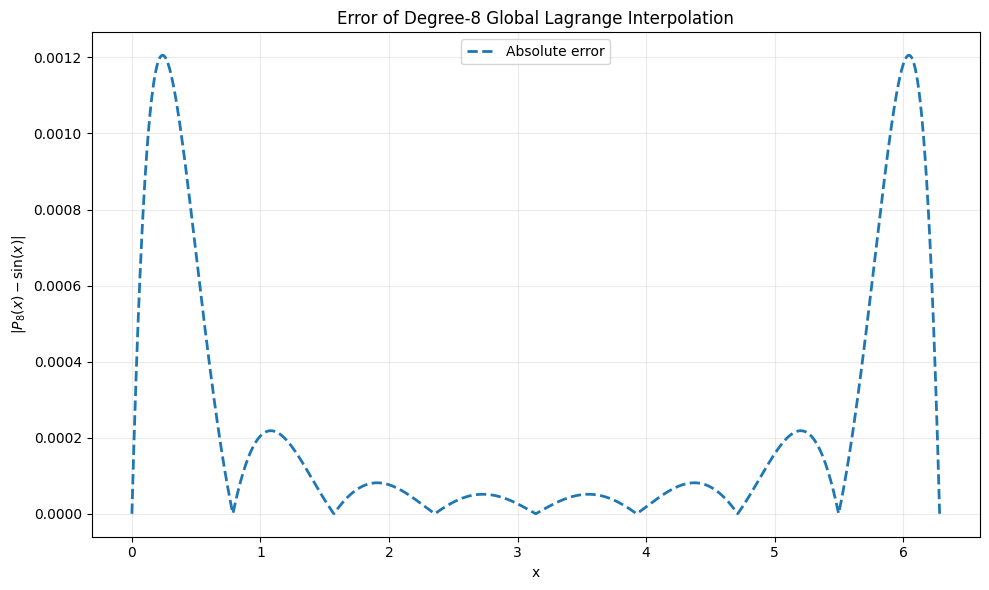

八次全局拉格朗日插值多项式：
           8            7            6           5           4
1.042e-18 x + 0.000153 x - 0.003364 x + 0.02362 x - 0.03899 x
           3           2
 - 0.1104 x - 0.04216 x + 1.012 x


In [5]:
# 八次全局拉格朗日插值曲线
plt.figure(figsize=(10, 6))
plt.scatter(x_nodes, y_nodes, s=60, label="Nine data points", zorder=3)
plt.plot(x, y_degree8, linewidth=2, label="Degree-8 Lagrange interpolation")
plt.plot(x, y_true, "--", linewidth=2, label="True function: sin(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Degree-8 Global Lagrange Interpolation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/degree8_lagrange.png", dpi=300, bbox_inches="tight")
plt.show()

# 八次全局拉格朗日插值误差
plt.figure(figsize=(10, 6))
plt.plot(x, error_degree8, "--", linewidth=2, label="Absolute error")
plt.xlabel("x")
plt.ylabel(r"$|P_8(x)-\sin(x)|$")
plt.title("Error of Degree-8 Global Lagrange Interpolation")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/degree8_lagrange_error.png", dpi=300, bbox_inches="tight")
plt.show()

print("八次全局拉格朗日插值多项式：")
print(polynomial_degree8)

/tmp/ipykernel_518500/926755944.py:14: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/lagrange_comparison.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/926755944.py:14: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/lagrange_comparison.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/926755944.py:14: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/lagrange_comparison.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/926755944.py:14: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_r

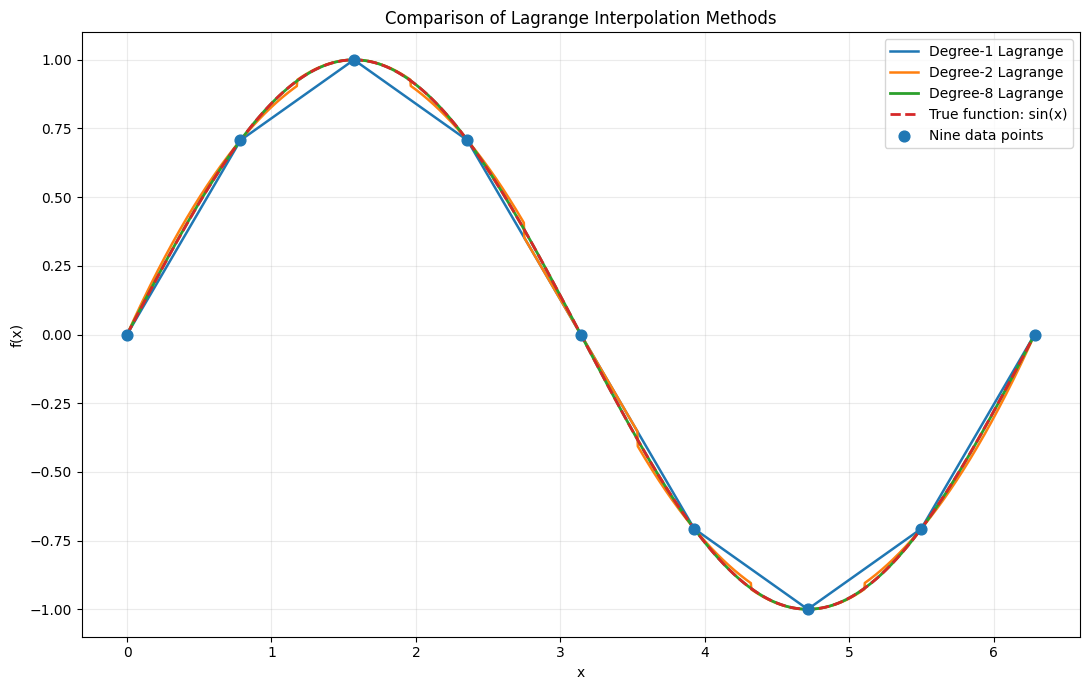

/tmp/ipykernel_518500/926755944.py:28: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/lagrange_error_comparison.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/926755944.py:28: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/lagrange_error_comparison.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/926755944.py:28: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/lagrange_error_comparison.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_518500/926755944.py:28: MatplotlibDeprecationWarning: savefig() got unexpected keyword argum

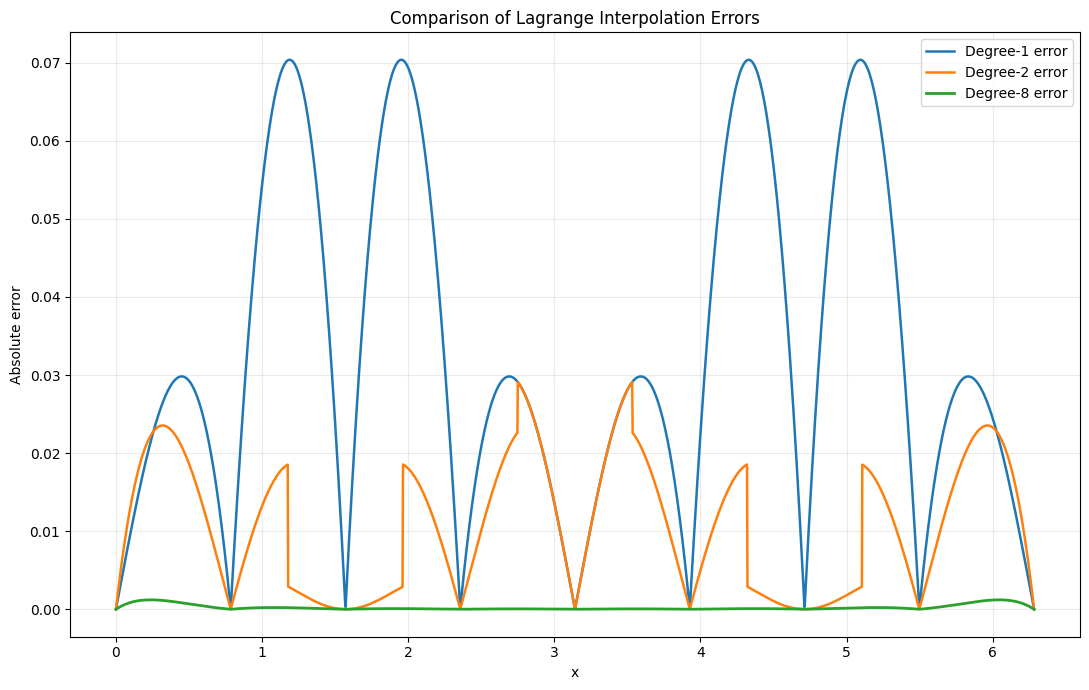

最大绝对误差比较：
一次拉格朗日插值：7.0377495883e-02
二次拉格朗日插值：2.9097277758e-02
八次拉格朗日插值：1.2055371436e-03


In [6]:
# 三种拉格朗日插值曲线比较
plt.figure(figsize=(11, 7))
plt.scatter(x_nodes, y_nodes, s=60, label="Nine data points", zorder=4)
plt.plot(x, y_linear, linewidth=1.8, label="Degree-1 Lagrange")
plt.plot(x, y_quadratic, linewidth=1.8, label="Degree-2 Lagrange")
plt.plot(x, y_degree8, linewidth=2, label="Degree-8 Lagrange")
plt.plot(x, y_true, "--", linewidth=2, label="True function: sin(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Comparison of Lagrange Interpolation Methods")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/lagrange_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 三种拉格朗日插值误差比较
plt.figure(figsize=(11, 7))
plt.plot(x, error_linear, linewidth=1.8, label="Degree-1 error")
plt.plot(x, error_quadratic, linewidth=1.8, label="Degree-2 error")
plt.plot(x, error_degree8, linewidth=2, label="Degree-8 error")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.title("Comparison of Lagrange Interpolation Errors")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("Figures/lagrange_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("最大绝对误差比较：")
print(f"一次拉格朗日插值：{np.max(error_linear):.10e}")
print(f"二次拉格朗日插值：{np.max(error_quadratic):.10e}")
print(f"八次拉格朗日插值：{np.max(error_degree8):.10e}")